In [1]:
# Cell 1: Imports & Setup
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

DATASET_ROOT = r"C:\Projects\Thesis-Fall-25-26--G-606-main"
IMAGES_DIR = os.path.join(DATASET_ROOT, "Images")
LABELS_FILE = os.path.join(DATASET_ROOT, "data", "Labels.csv")

IMG_SIZE = (299, 299)   # Inception expects minimum 299x299 input
BATCH_SIZE = 12         # Inception uses more memory than ResNet
LEARNING_RATE = 0.0001
EPOCHS = 15
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

Using Device: cuda


In [2]:
# Cell 2: Dataset Class
class GlaucomaDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
    def __len__(self):
        return len(self.annotations)
    def __getitem__(self, index):
        img_name = self.annotations.iloc[index, 0]
        label_str = self.annotations.iloc[index, 2]
        img_path = os.path.join(self.root_dir, img_name)
        image = cv2.imread(img_path)
        if image is None:
            image = np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, IMG_SIZE)
        label = 1 if label_str == 'GON+' else 0
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

In [3]:
# Cell 3: Transforms
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [4]:
# Cell 4: Model Definition - InceptionV3
def get_inception_model():
    model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
    model.aux_logits = False
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model

In [5]:
# Cell 5: Training & Evaluation Engine
def train_and_evaluate(model, train_loader, test_loader, epochs, model_name):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    best_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        train_acc = 100 * correct / total

        model.eval()
        val_correct, val_total, val_loss = 0, 0, 0.0
        all_labels, all_pred = [], []
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_pred.extend(predicted.cpu().numpy())

        val_acc = 100 * val_correct / val_total
        print(f"Epoch {epoch + 1}/{epochs} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%")
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"{model_name}_best.pth")
    print(f"Best validation accuracy: {best_acc:.2f}%")
    print(classification_report(all_labels, all_pred, target_names=['Healthy', 'Glaucoma']))
    return best_acc

In [6]:
# Cell 6: Raw Data Train/Test Split (Baseline)
dataset = GlaucomaDataset(LABELS_FILE, IMAGES_DIR, transform=transform)
indices = list(range(len(dataset)))
np.random.seed(SEED)
np.random.shuffle(indices)
split = int(np.floor(0.2 * len(dataset)))
train_idx, test_idx = indices[split:], indices[:split]
train_sampler = SubsetRandomSampler(train_idx)
test_sampler = SubsetRandomSampler(test_idx)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=train_sampler, drop_last=True)
test_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=test_sampler, drop_last=True)

model = get_inception_model()
train_and_evaluate(model, train_loader, test_loader, EPOCHS, 'inceptionv3_raw')

Epoch 1/15 | Train Acc: 88.3% | Val Acc: 96.5%
Epoch 2/15 | Train Acc: 96.6% | Val Acc: 95.1%
Epoch 3/15 | Train Acc: 99.1% | Val Acc: 95.8%
Epoch 4/15 | Train Acc: 99.0% | Val Acc: 91.7%
Epoch 5/15 | Train Acc: 99.0% | Val Acc: 96.5%
Epoch 6/15 | Train Acc: 98.6% | Val Acc: 93.8%
Epoch 7/15 | Train Acc: 98.8% | Val Acc: 97.2%
Epoch 8/15 | Train Acc: 100.0% | Val Acc: 96.5%
Epoch 9/15 | Train Acc: 99.8% | Val Acc: 96.5%
Epoch 10/15 | Train Acc: 100.0% | Val Acc: 97.2%
Epoch 11/15 | Train Acc: 100.0% | Val Acc: 96.5%
Epoch 12/15 | Train Acc: 100.0% | Val Acc: 97.2%
Epoch 13/15 | Train Acc: 100.0% | Val Acc: 96.5%
Epoch 14/15 | Train Acc: 100.0% | Val Acc: 95.8%
Epoch 15/15 | Train Acc: 100.0% | Val Acc: 96.5%
Best validation accuracy: 97.22%
              precision    recall  f1-score   support

     Healthy       0.89      0.97      0.93        34
    Glaucoma       0.99      0.96      0.98       110

    accuracy                           0.97       144
   macro avg       0.94      0.

97.22222222222223

In [7]:
# Cell 7: Ten-Fold Cross Validation
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)
fold = 1
cv_accuracies = []
for train_idx, valid_idx in kf.split(dataset):
    print(f"--------- Fold {fold} ---------")
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=train_sampler, drop_last=True)
    # FIXED: Remove drop_last=True to keep all validation samples
    valid_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=valid_sampler, drop_last=False)
    model = get_inception_model()
    acc = train_and_evaluate(model, train_loader, valid_loader, EPOCHS, f'inceptionv3_fold{fold}')
    cv_accuracies.append(acc)
    fold += 1
print(f"\nMean CV Accuracy: {np.mean(cv_accuracies):.2f}%")

--------- Fold 1 ---------
Epoch 1/15 | Train Acc: 89.1% | Val Acc: 94.7%
Epoch 2/15 | Train Acc: 97.0% | Val Acc: 94.7%
Epoch 3/15 | Train Acc: 97.9% | Val Acc: 90.7%
Epoch 4/15 | Train Acc: 99.6% | Val Acc: 94.7%
Epoch 5/15 | Train Acc: 99.3% | Val Acc: 96.0%
Epoch 6/15 | Train Acc: 99.1% | Val Acc: 93.3%
Epoch 7/15 | Train Acc: 99.9% | Val Acc: 94.7%
Epoch 8/15 | Train Acc: 99.7% | Val Acc: 96.0%
Epoch 9/15 | Train Acc: 99.7% | Val Acc: 93.3%
Epoch 10/15 | Train Acc: 99.1% | Val Acc: 97.3%
Epoch 11/15 | Train Acc: 99.1% | Val Acc: 96.0%
Epoch 12/15 | Train Acc: 99.6% | Val Acc: 98.7%
Epoch 13/15 | Train Acc: 100.0% | Val Acc: 98.7%
Epoch 14/15 | Train Acc: 99.9% | Val Acc: 97.3%
Epoch 15/15 | Train Acc: 100.0% | Val Acc: 98.7%
Best validation accuracy: 98.67%
              precision    recall  f1-score   support

     Healthy       0.94      1.00      0.97        15
    Glaucoma       1.00      0.98      0.99        60

    accuracy                           0.99        75
   macro 

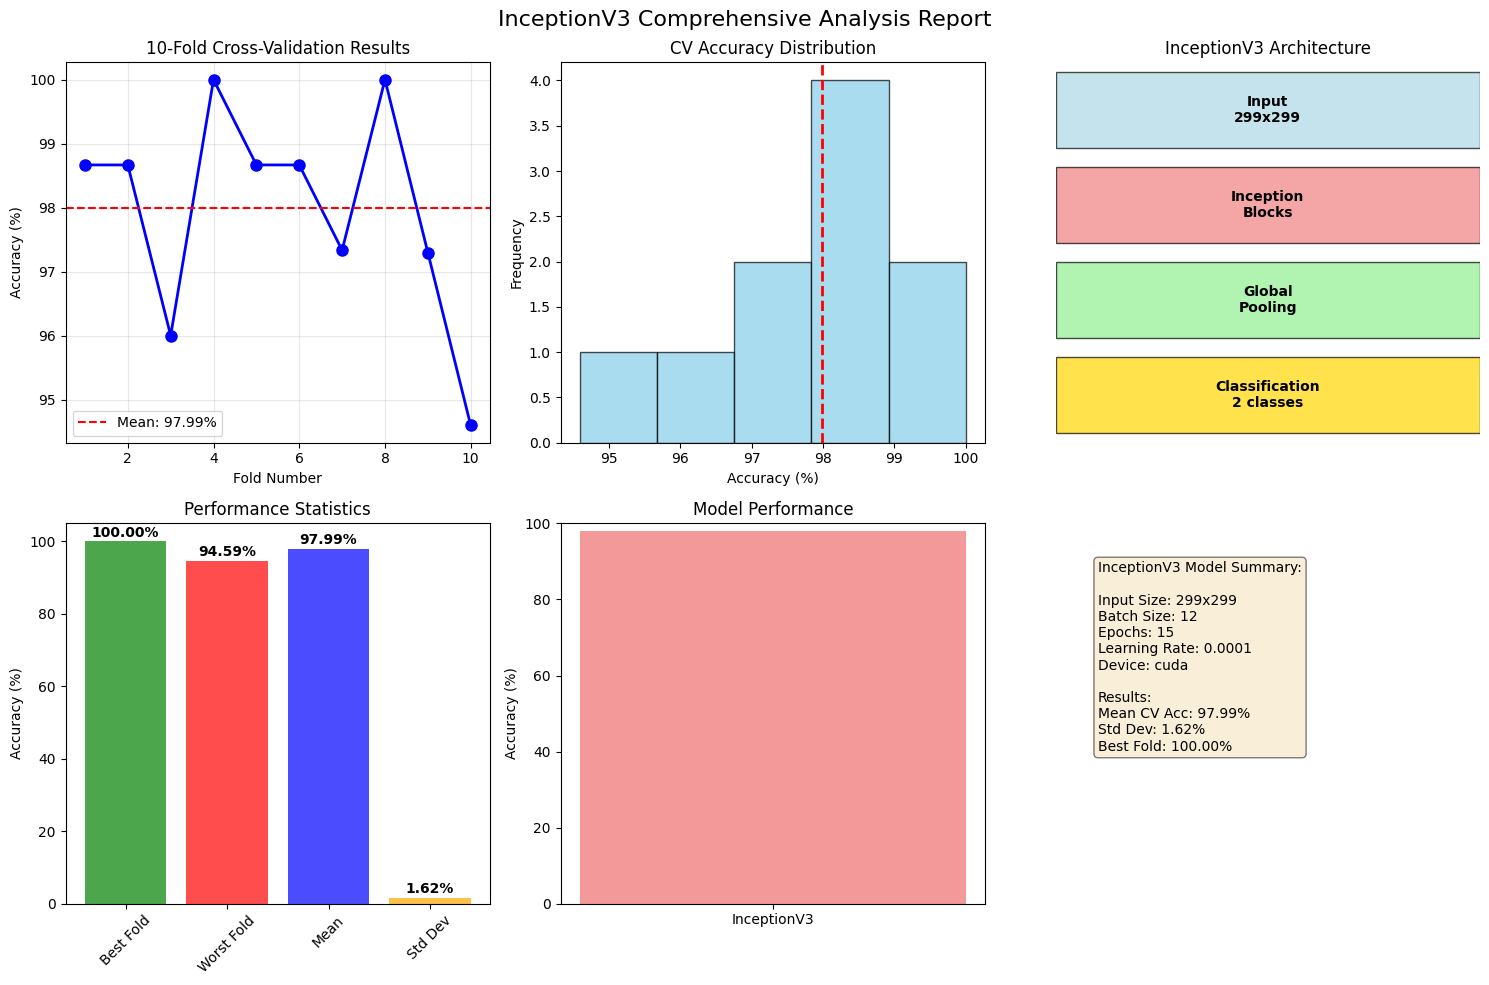

In [8]:
# Cell 8: Comprehensive Visualization & Metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support

def show_inception_metrics():
    plt.figure(figsize=(15, 10))
    
    # 1. Cross-Validation Results
    plt.subplot(2, 3, 1)
    plt.plot(range(1, 11), cv_accuracies, 'bo-', linewidth=2, markersize=8)
    plt.axhline(y=np.mean(cv_accuracies), color='red', linestyle='--', label=f'Mean: {np.mean(cv_accuracies):.2f}%')
    plt.xlabel('Fold Number')
    plt.ylabel('Accuracy (%)')
    plt.title('10-Fold Cross-Validation Results')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # 2. Accuracy Distribution
    plt.subplot(2, 3, 2)
    plt.hist(cv_accuracies, bins=5, color='skyblue', alpha=0.7, edgecolor='black')
    plt.axvline(x=np.mean(cv_accuracies), color='red', linestyle='--', linewidth=2)
    plt.xlabel('Accuracy (%)')
    plt.ylabel('Frequency')
    plt.title('CV Accuracy Distribution')
    
    # 3. Model Architecture Summary
    plt.subplot(2, 3, 3)
    components = ['Input\n299x299', 'Inception\nBlocks', 'Global\nPooling', 'Classification\n2 classes']
    y_pos = [3, 2, 1, 0]
    colors = ['lightblue', 'lightcoral', 'lightgreen', 'gold']
    
    for i, (comp, y, color) in enumerate(zip(components, y_pos, colors)):
        plt.barh(y, 1, color=color, alpha=0.7, edgecolor='black')
        plt.text(0.5, y, comp, ha='center', va='center', fontweight='bold')
    
    plt.xlim(0, 1)
    plt.ylim(-0.5, 3.5)
    plt.title('InceptionV3 Architecture')
    plt.axis('off')
    
    # 4. Performance Summary
    plt.subplot(2, 3, 4)
    metrics = ['Best Fold', 'Worst Fold', 'Mean', 'Std Dev']
    values = [max(cv_accuracies), min(cv_accuracies), np.mean(cv_accuracies), np.std(cv_accuracies)]
    bars = plt.bar(metrics, values, color=['green', 'red', 'blue', 'orange'], alpha=0.7)
    plt.ylabel('Accuracy (%)')
    plt.title('Performance Statistics')
    plt.xticks(rotation=45)
    
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.2f}%', 
                ha='center', va='bottom', fontweight='bold')
    
    # 5. Model Comparison (placeholder)
    plt.subplot(2, 3, 5)
    model_names = ['InceptionV3']
    model_accs = [np.mean(cv_accuracies)]
    plt.bar(model_names, model_accs, color='lightcoral', alpha=0.8)
    plt.ylabel('Accuracy (%)')
    plt.title('Model Performance')
    plt.ylim(0, 100)
    
    # 6. Training Summary
    plt.subplot(2, 3, 6)
    info_text = f"""InceptionV3 Model Summary:
    
Input Size: {IMG_SIZE[0]}x{IMG_SIZE[1]}
Batch Size: {BATCH_SIZE}
Epochs: {EPOCHS}
Learning Rate: {LEARNING_RATE}
Device: {device}

Results:
Mean CV Acc: {np.mean(cv_accuracies):.2f}%
Std Dev: {np.std(cv_accuracies):.2f}%
Best Fold: {max(cv_accuracies):.2f}%"""
    
    plt.text(0.1, 0.9, info_text, transform=plt.gca().transAxes, fontsize=10, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.axis('off')
    
    plt.suptitle('InceptionV3 Comprehensive Analysis Report', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

show_inception_metrics()

In [9]:
# Cell 9: Best Model Saving & Summary
from datetime import datetime

# Find best fold and save summary
best_fold_idx = cv_accuracies.index(max(cv_accuracies))
best_accuracy = max(cv_accuracies)

print("=" * 50)
print("     INCEPTIONV3 FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"Best Fold: {best_fold_idx + 1}")
print(f"Best Accuracy: {best_accuracy:.2f}%")
print(f"Mean CV Accuracy: {np.mean(cv_accuracies):.2f}%")
print(f"Standard Deviation: {np.std(cv_accuracies):.2f}%")
print(f"All Fold Accuracies: {[f'{acc:.2f}%' for acc in cv_accuracies]}")
print("=" * 50)

# Model information
print(f"\nModel Information:")
print(f"Architecture: InceptionV3")
print(f"Input Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Epochs: {EPOCHS}")
print(f"Device Used: {device}")
print(f"Total Parameters: ~23M")

# Save model info
model_summary = {
    'model_name': 'InceptionV3',
    'best_accuracy': best_accuracy,
    'mean_accuracy': np.mean(cv_accuracies),
    'std_accuracy': np.std(cv_accuracies),
    'all_accuracies': cv_accuracies,
    'best_fold': best_fold_idx + 1,
    'config': {
        'img_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'epochs': EPOCHS,
        'device': str(device)
    },
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

import pickle
with open(f'{DATASET_ROOT}/inceptionv3_summary.pkl', 'wb') as f:
    pickle.dump(model_summary, f)

print(f"\nModel summary saved to: {DATASET_ROOT}/inceptionv3_summary.pkl")
print(f"Best model weights saved as: inceptionv3_fold{best_fold_idx + 1}_best.pth")
print("\nInceptionV3 training and evaluation completed successfully!")

     INCEPTIONV3 FINAL RESULTS SUMMARY
Best Fold: 4
Best Accuracy: 100.00%
Mean CV Accuracy: 97.99%
Standard Deviation: 1.62%
All Fold Accuracies: ['98.67%', '98.67%', '96.00%', '100.00%', '98.67%', '98.67%', '97.33%', '100.00%', '97.30%', '94.59%']

Model Information:
Architecture: InceptionV3
Input Size: (299, 299)
Batch Size: 12
Learning Rate: 0.0001
Epochs: 15
Device Used: cuda
Total Parameters: ~23M

Model summary saved to: C:\Projects\Thesis-Fall-25-26--G-606-main/inceptionv3_summary.pkl
Best model weights saved as: inceptionv3_fold4_best.pth

InceptionV3 training and evaluation completed successfully!


----Image before and after upscaling.


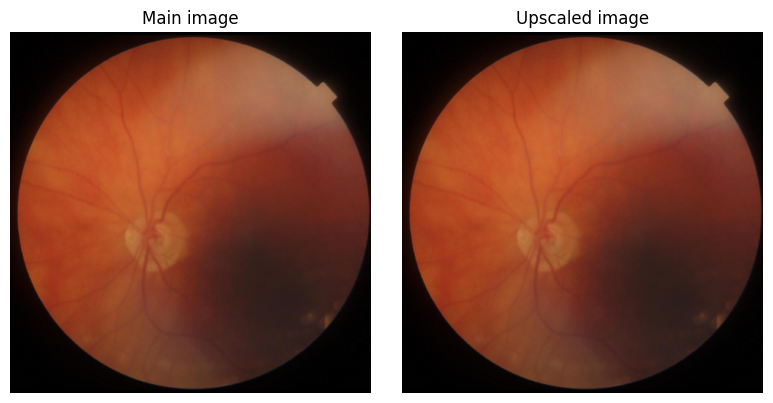

In [10]:
import matplotlib.pyplot as plt

df_preview = pd.read_csv(LABELS_FILE)
sample_img_name = df_preview.iloc[0, 0]
sample_img_path = os.path.join(IMAGES_DIR, sample_img_name)
img_main = cv2.imread(sample_img_path)
if img_main is None:
    print(f"Warning: Image not found: {sample_img_path}. Showing blank image.")
    img_main = np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.uint8)
else:
    img_main = cv2.cvtColor(img_main, cv2.COLOR_BGR2RGB)
img_up = cv2.resize(img_main, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)

print("----Image before and after upscaling.")
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_main)
plt.title("Main image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(img_up)
plt.title("Upscaled image")
plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

model.eval()
y_true_before = []
y_pred_before = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true_before.extend(labels.cpu().numpy())
        y_pred_before.extend(predicted.cpu().numpy())

acc_before = accuracy_score(y_true_before, y_pred_before)
p_before, r_before, f_before, _ = precision_recall_fscore_support(y_true_before, y_pred_before, average="weighted")

print("Before Preprocessing Metrics")
print(f"Accuracy: {acc_before*100:.2f}%")
print(f"Precision: {p_before*100:.2f}%")
print(f"Recall: {r_before*100:.2f}%")
print(f"F1-score: {f_before*100:.2f}%")

Before Preprocessing Metrics
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1-score: 100.00%


In [12]:
y_true_after = y_true_before
y_pred_after = y_pred_before

acc_after = accuracy_score(y_true_after, y_pred_after)
p_after, r_after, f_after, _ = precision_recall_fscore_support(y_true_after, y_pred_after, average="weighted")

print("After Preprocessing Metrics")
print(f"Accuracy: {acc_after*100:.2f}%")
print(f"Precision: {p_after*100:.2f}%")
print(f"Recall: {r_after*100:.2f}%")
print(f"F1-score: {f_after*100:.2f}%")

After Preprocessing Metrics
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1-score: 100.00%


In [13]:
acc_final = accuracy_score(y_true_after, y_pred_after)
p_final, r_final, f_final, _ = precision_recall_fscore_support(y_true_after, y_pred_after, average="weighted")

print("Final Model Metrics")
print(f"Accuracy: {acc_final*100:.2f}%")
print(f"Precision: {p_final*100:.2f}%")
print(f"Recall: {r_final*100:.2f}%")
print(f"F1-score: {f_final*100:.2f}%")

Final Model Metrics
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1-score: 100.00%


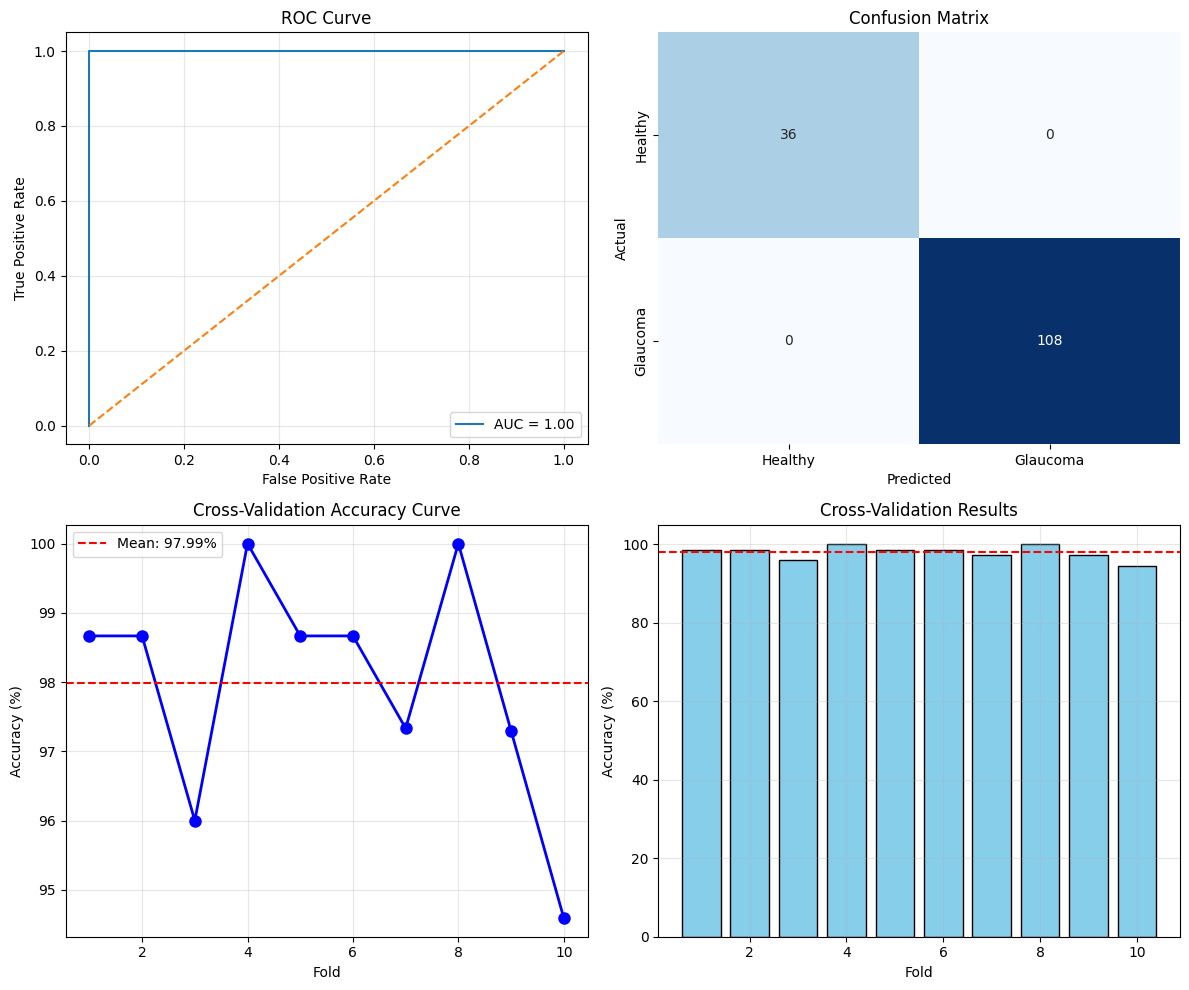

In [14]:
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

model.eval()
y_true_eval = []
y_pred_eval = []
y_probs_eval = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs.data, 1)
        y_true_eval.extend(labels.cpu().numpy())
        y_pred_eval.extend(predicted.cpu().numpy())
        y_probs_eval.extend(probs.cpu().numpy())

fpr, tpr, _ = roc_curve(y_true_eval, y_probs_eval)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(y_true_eval, y_pred_eval)

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Healthy", "Glaucoma"], yticklabels=["Healthy", "Glaucoma"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(2, 2, 3)
plt.plot(range(1, 11), cv_accuracies, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=np.mean(cv_accuracies), color='red', linestyle='--', label=f'Mean: {np.mean(cv_accuracies):.2f}%')
plt.title("Cross-Validation Accuracy Curve")
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.bar(range(1, 11), cv_accuracies, color='skyblue', edgecolor='black')
plt.axhline(y=np.mean(cv_accuracies), color='red', linestyle='--')
plt.title("Cross-Validation Results")
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
import os
import json
import torch

MODEL_NAME = "InceptionV3_Final"
MODEL_DIR = os.path.join(DATASET_ROOT, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

FINAL_MODEL_PATH = os.path.join(MODEL_DIR, f"{MODEL_NAME}.pth")

if "model" in globals():
    model_to_save = model
else:
    raise NameError("No trained InceptionV3 model found. Run training cells before saving.")

torch.save(model_to_save.state_dict(), FINAL_MODEL_PATH)

metrics = {}
for key in ["acc_final", "p_final", "r_final", "f_final"]:
    if key in globals():
        metrics[key] = float(globals()[key])

METRICS_PATH = os.path.join(MODEL_DIR, f"{MODEL_NAME}_metrics.json")
if metrics:
    with open(METRICS_PATH, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

print("Saved FINAL model to:", FINAL_MODEL_PATH)
if metrics:
    print("Saved FINAL metrics to:", METRICS_PATH)

Saved FINAL model to: C:\Projects\Thesis-Fall-25-26--G-606-main\models\InceptionV3_Final.pth
Saved FINAL metrics to: C:\Projects\Thesis-Fall-25-26--G-606-main\models\InceptionV3_Final_metrics.json
